# 04 · Evaluation

Test-set results for every checkpoint that exists.

1. **Decoding tuned per model on val** (greedy, plus beam k ∈ {2,3,5,7} × α ∈ {0, 0.5, 1}).
2. **Test split scored once** with the standard `pycocoevalcap` pipeline (PTB tokenizer, BLEU, METEOR, ROUGE-L, CIDEr-D), shown ×100 as papers report them.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import ImageFeatureDataset, load_processed, reference_captions, split_images
from src.decoding import generate_captions
from src.models import load_checkpoint
from src.utils import caption_scores, official_scores

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
RESULTS = ROOT / "results" / "evaluation"
RESULTS.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda")

features, images, vocab = load_processed(ROOT / "data" / "processed")
val_images, test_images = split_images(images, "val"), split_images(images, "test")
val_refs = reference_captions(val_images)
val_loader = DataLoader(ImageFeatureDataset(features, val_images), batch_size=256)
test_loader = DataLoader(ImageFeatureDataset(features, test_images), batch_size=256)
test_refs_raw = {img["filename"]: img["captions"] for img in test_images}
warmup_loader = DataLoader(ImageFeatureDataset(features, val_images[:256]), batch_size=256)

MODELS = {
    "Transformer · XE": "transformer_xe.pt",
    "Transformer · SCST": "transformer_scst.pt",
    "LSTM + attention · XE": "lstm_xe.pt",
    "LSTM + attention · SCST": "lstm_scst.pt",
}
MODELS = {name: f for name, f in MODELS.items() if (ROOT / "checkpoints" / f).exists()}
display(viz.table(pd.DataFrame([{"model": n, "checkpoint": f} for n, f in MODELS.items()]), caption="Models found"))

model,checkpoint
Transformer · XE,transformer_xe.pt
Transformer · SCST,transformer_scst.pt
LSTM + attention · XE,lstm_xe.pt
LSTM + attention · SCST,lstm_scst.pt


## 1. Tune decoding on val (per model)

In [2]:
BEAM_SIZES, LENGTH_PENALTIES = [2, 3, 5, 7], [0.0, 0.5, 1.0]
models, sweep_rows, decoding = {}, [], {}
for name, fname in MODELS.items():
    model, ckpt = load_checkpoint(ROOT / "checkpoints" / fname, device)
    models[name] = model
    candidates = [(1, 0.0)] + [(k, a) for k in BEAM_SIZES for a in LENGTH_PENALTIES]
    for k, alpha in candidates:
        caps = generate_captions(model, val_loader, vocab, device, beam_size=k, length_penalty=alpha)
        sweep_rows.append({"model": name, "beam size": k, "α": alpha, **caption_scores(val_refs, caps)})
    rows = pd.DataFrame([r for r in sweep_rows if r["model"] == name])
    best = rows.loc[rows[rows["beam size"] > 1].CIDEr.idxmax()]
    decoding[name] = {"beam_size": int(best["beam size"]), "length_penalty": float(best["α"])}

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(RESULTS / "decoding_sweep_val.csv", index=False)
(RESULTS / "decoding_choice.json").write_text(json.dumps(decoding, indent=2))

choice = pd.DataFrame([
    {"model": n, "greedy val CIDEr": sweep[(sweep.model == n) & (sweep["beam size"] == 1)].CIDEr.iloc[0],
     "tuned beam": f"k={d['beam_size']}, α={d['length_penalty']:g}",
     "beam val CIDEr": sweep[(sweep.model == n) & (sweep["beam size"] == d["beam_size"]) & (sweep["α"] == d["length_penalty"])].CIDEr.iloc[0]}
    for n, d in decoding.items()])
display(viz.table(choice, caption="Decoding chosen on val (fast CIDEr, ×1)"))

model,greedy val CIDEr,tuned beam,beam val CIDEr
Transformer · XE,0.476,"k=7, α=1",0.509
Transformer · SCST,0.559,"k=7, α=0.5",0.567
LSTM + attention · XE,0.463,"k=5, α=1",0.491
LSTM + attention · SCST,0.548,"k=2, α=0.5",0.550


## 2. Test set: official metrics

In [3]:
METRICS = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]
test_rows, per_image_cider, test_captions = [], {}, {}
for name, model in models.items():
    for label, cfg in [("greedy", {"beam_size": 1, "length_penalty": 0.0}), ("beam", decoding[name])]:
        generate_captions(model, warmup_loader, vocab, device, **cfg)  # warm-up, so timing excludes kernel selection
        torch.cuda.synchronize()
        start = time.time()
        caps = generate_captions(model, test_loader, vocab, device, **cfg)
        torch.cuda.synchronize()
        seconds = time.time() - start
        scores, per_img = official_scores(test_refs_raw, caps, per_image=True)
        key = f"{name} · {label}"
        test_captions[key], per_image_cider[key] = caps, per_img
        decoder, training = name.split(" · ")
        test_rows.append({"decoder": decoder, "training": training, "decoding": label if label == "greedy" else
                          f"beam (k={cfg['beam_size']}, α={cfg['length_penalty']:g})",
                          **{m: 100 * scores[m] for m in METRICS}, "images / sec": len(caps) / seconds})

test_metrics = pd.DataFrame(test_rows)
test_metrics.to_csv(RESULTS / "test_metrics.csv", index=False)
(RESULTS / "test_captions.json").write_text(json.dumps(test_captions, indent=2))
(RESULTS / "per_image_cider.json").write_text(json.dumps(per_image_cider))
display(viz.table(test_metrics, precision=1, maximize=METRICS, formats={"images / sec": "{:.0f}"},
                  caption="Karpathy test split (1,000 images), pycocoevalcap metrics ×100"))

best_row = test_metrics.loc[test_metrics.CIDEr.idxmax()]
viz.note(f"Best test CIDEr: <b>{best_row.CIDEr:.1f}</b> ({best_row.decoder}, {best_row.training}, {best_row.decoding}), "
         f"BLEU-4 {best_row['BLEU-4']:.1f}, METEOR {best_row.METEOR:.1f}")

decoder,training,decoding,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,CIDEr,images / sec
Transformer,XE,greedy,65.4,46.7,32.6,22.8,19.6,45.4,48.7,278
Transformer,XE,"beam (k=7, α=1)",65.4,47.1,33.6,23.9,20.3,46.2,52.7,86
Transformer,SCST,greedy,67.8,48.9,34.6,24.4,20.1,46.7,56.6,830
Transformer,SCST,"beam (k=7, α=0.5)",68.4,49.7,35.5,25.3,20.3,47.1,58.3,105
LSTM + attention,XE,greedy,62.3,43.5,29.9,20.4,19.5,44.8,46.3,2060
LSTM + attention,XE,"beam (k=5, α=1)",62.3,43.7,30.3,21.0,20.3,45.5,48.8,627
LSTM + attention,SCST,greedy,67.9,48.8,34.3,24.1,20.1,46.6,55.5,2571
LSTM + attention,SCST,"beam (k=2, α=0.5)",68.1,49.1,34.9,24.7,20.2,46.7,56.8,1118


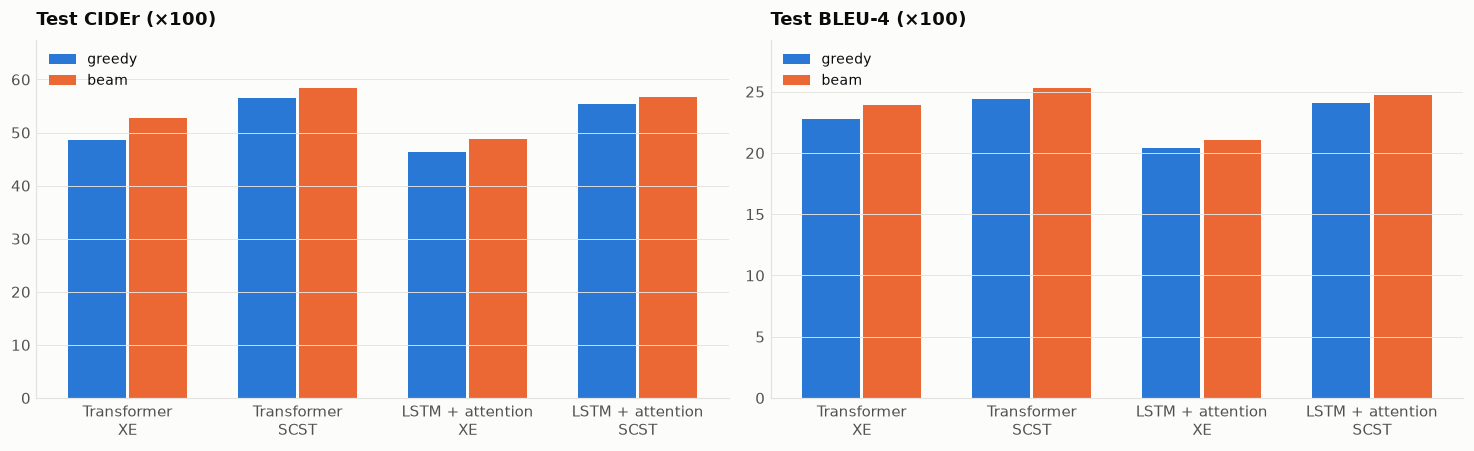

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
labels = [f"{r.decoder}\n{r.training}" for r in test_metrics[test_metrics.decoding == "greedy"].itertuples()]
x = np.arange(len(labels))
for ax, metric in zip(axes, ["CIDEr", "BLEU-4"]):
    for i, (label, color) in enumerate([("greedy", viz.SERIES[0]), ("beam", viz.SERIES[1])]):
        vals = test_metrics[test_metrics.decoding.str.startswith(label)][metric].to_numpy()
        ax.bar(x + (i - 0.5) * 0.36, vals, width=0.34, color=color, label=label)
    ax.set_xticks(x, labels)
    ax.set(title=f"Test {metric} (×100)")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
plt.tight_layout()
plt.savefig(RESULTS / "test_metrics.png")
plt.show()

## 3. Context: human agreement and published results
One reference scored against the other four, plus published Flickr30k numbers. The encoders differ, so these are context, not a controlled comparison.

In [5]:
rng = np.random.default_rng(0)
held = {f: int(rng.integers(5)) for f in test_refs_raw}
human = official_scores({f: [c for i, c in enumerate(r) if i != held[f]] for f, r in test_refs_raw.items()},
                        {f: r[held[f]] for f, r in test_refs_raw.items()})

published = pd.DataFrame([
    {"system": "Deep Visual-Semantic Alignments (Karpathy & Fei-Fei, 2015)", "encoder": "VGG-16", "BLEU-1": 57.3, "BLEU-4": 15.7, "METEOR": 15.3, "CIDEr": 24.7},
    {"system": "Show, Attend and Tell, soft attention (Xu et al., 2015)", "encoder": "VGG-19", "BLEU-1": 66.7, "BLEU-4": 19.1, "METEOR": 18.5, "CIDEr": np.nan},
    {"system": "Show, Attend and Tell, hard attention (Xu et al., 2015)", "encoder": "VGG-19", "BLEU-1": 66.9, "BLEU-4": 19.9, "METEOR": 18.5, "CIDEr": np.nan},
    {"system": "Adaptive attention (Lu et al., 2017)", "encoder": "ResNet-152, fine-tuned", "BLEU-1": 67.7, "BLEU-4": 25.1, "METEOR": 20.4, "CIDEr": 53.1},
])
ours = test_metrics.sort_values("CIDEr", ascending=False).drop_duplicates(["decoder", "training"])
ours_rows = [{"system": f"ours: {r['decoder']}, {r['training']}, {r['decoding']}", "encoder": "ResNet-50, frozen, 7×7 grid",
              "BLEU-1": r["BLEU-1"], "BLEU-4": r["BLEU-4"], "METEOR": r["METEOR"], "CIDEr": r["CIDEr"]} for _, r in ours.iterrows()]
human_row = [{"system": "human (leave-one-out, 4 references)", "encoder": "",
              **{m: 100 * human[m] for m in ["BLEU-1", "BLEU-4", "METEOR", "CIDEr"]}}]
context = pd.concat([pd.DataFrame(ours_rows), published, pd.DataFrame(human_row)], ignore_index=True)
display(viz.table(context, precision=1, caption="Flickr30k test (×100). Published numbers as reported in each paper",
                  formats={"CIDEr": lambda v: "–" if pd.isna(v) else f"{v:.1f}"}))

system,encoder,BLEU-1,BLEU-4,METEOR,CIDEr
"ours: Transformer, SCST, beam (k=7, α=0.5)","ResNet-50, frozen, 7×7 grid",68.4,25.3,20.3,58.3
"ours: LSTM + attention, SCST, beam (k=2, α=0.5)","ResNet-50, frozen, 7×7 grid",68.1,24.7,20.2,56.8
"ours: Transformer, XE, beam (k=7, α=1)","ResNet-50, frozen, 7×7 grid",65.4,23.9,20.3,52.7
"ours: LSTM + attention, XE, beam (k=5, α=1)","ResNet-50, frozen, 7×7 grid",62.3,21.0,20.3,48.8
"Deep Visual-Semantic Alignments (Karpathy & Fei-Fei, 2015)",VGG-16,57.3,15.7,15.3,24.7
"Show, Attend and Tell, soft attention (Xu et al., 2015)",VGG-19,66.7,19.1,18.5,–
"Show, Attend and Tell, hard attention (Xu et al., 2015)",VGG-19,66.9,19.9,18.5,–
"Adaptive attention (Lu et al., 2017)","ResNet-152, fine-tuned",67.7,25.1,20.4,53.1
"human (leave-one-out, 4 references)",,60.8,19.0,23.3,68.2


## Summary

- **Tuned beams differ per model**: cross-entropy models want wide beams with α=1, SCST models want α=0.5 and the LSTM only k=2 (SCST already sharpens the output).
- **Best: Transformer + SCST + beam — BLEU-4 25.3, METEOR 20.3, ROUGE-L 47.1, CIDEr 58.3.** The LSTM + SCST reaches 56.8.
- Above the published Show, Attend and Tell (BLEU-4 19.9) and Adaptive Attention (CIDEr 53.1) results, though those use different, fine-tuned encoders.
- Human leave-one-out: CIDEr 68.2 but BLEU-4 19.0, so models beat humans on n-gram overlap while CIDEr still leaves a gap.